In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [2]:
books = []

for page in range(1, 51):

    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)

    soup = BeautifulSoup(response.text, "html.parser")

In [3]:
for book in soup.find_all("article", class_="product_pod"):

        title = book.h3.a["title"]

        price = book.find("p", class_="price_color").text

        availability = book.find(
            "p",
            class_="instock availability"
        ).text.strip()

        rating = book.p["class"][1]

        books.append([title, price, availability, rating])

df = pd.DataFrame(
    books,
    columns=["Title", "Price", "Availability", "Rating"]
)

df.to_csv("books.csv", index=False)

print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
                              Title    Price Availability Rating
0                      Frankenstein  Â£38.00     In stock    Two
1  Forever Rockers (The Rocker #12)  Â£28.80     In stock  Three
2       Fighting Fate (Fighting #6)  Â£39.24     In stock  Three
3                              Emma  Â£32.93     In stock    Two
4                   Eat, Pray, Love  Â£51.32     In stock  Three



First 10 Records:

+----+---------------------------------------------------------------+---------+----------------+----------+
|    | Title                                                         | Price   | Availability   | Rating   |
+====+===============================================================+=========+================+==========+
|  0 | Frankenstein                                                  | Â£38.00 | In stock       | Two      |
+----+---------------------------------------------------------------+---------+----------------+----------+
|  1 | Forever Rockers (The Rocker #12)                              | Â£28.80 | In stock       | Three    |
+----+---------------------------------------------------------------+---------+----------------+----------+
|  2 | Fighting Fate (Fighting #6)                                   | Â£39.24 | In stock       | Three    |
+----+---------------------------------------------------------------+---------+----------------+----------+

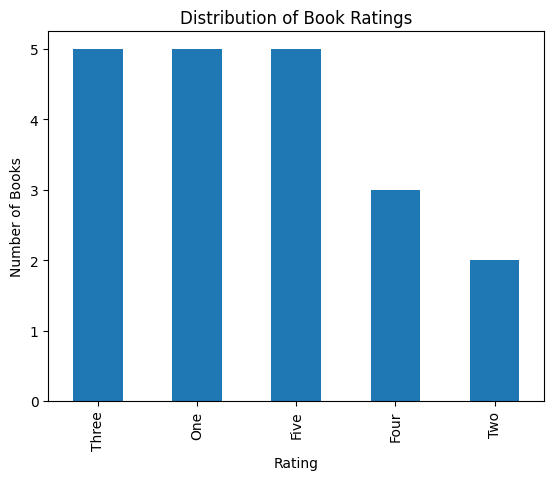

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

df = pd.read_csv("books.csv")

print("\nFirst 10 Records:\n")
print(tabulate(df.head(10), headers="keys", tablefmt="grid"))

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nRating Distribution:")
print(df["Rating"].value_counts())

df.to_excel("books.xlsx", index=False)

rating_counts = df["Rating"].value_counts()

rating_counts.plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Ratings")

plt.show()